# 05_YOLO_Visualizer

- 환자 1명을 지정해 YOLO GT 박스와 Edi 시그널을 함께 시각화합니다.
- 데이터 기준: `4_BreathDetect_YOLO/20260301_win2000_stride1000`


In [30]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

DATASET_ROOT = Path('/home/jhkim/NAVA/02_YOLO/data/4_BreathDetect_YOLO/20260301_win2000_stride1000_nogrid_relative')
BREATH_ROOT = Path('/home/jhkim/NAVA/03_LABEL_BREATH/notebooks/outputs/03_breath_detect/20260301')
WINDOW_SIZE = 2000
STRIDE = 1000
CLASS_NAMES = {0: 'peak', 1: 'normal_breath', 2: 'abnormal_breath'}
CLASS_COLORS = {0: '#f39c12', 1: '#2ecc71', 2: '#e74c3c'}


In [31]:
def parse_yolo_labels(label_path: Path):
    rows = []
    if not label_path.exists():
        return rows
    for line in label_path.read_text(encoding='utf-8').splitlines():
        line = line.strip()
        if not line:
            continue
        c, xc, yc, w, h = line.split()
        rows.append({
            'class_id': int(c),
            'xc': float(xc),
            'yc': float(yc),
            'w': float(w),
            'h': float(h),
        })
    return rows


def y_norm_to_signal(y_norm, y_min, y_max):
    # preprocessing used: y_norm = (y_max - y) / (y_max - y_min)
    return y_max - (y_norm * (y_max - y_min))


def window_to_sample_range(window_idx: int, n_samples: int, window_size: int, stride: int):
    start = window_idx * stride
    end = min(start + window_size, n_samples)
    if start >= n_samples:
        raise ValueError(f'window_idx={window_idx} is out of range for n_samples={n_samples}')
    return start, end


In [32]:
def show_window(patient_id: str, window_idx: int, signal_col: str = 'edi_smooth_for_detection'):
    pid = str(patient_id).zfill(2)
    pdir = DATASET_ROOT / pid
    image_path = pdir / 'images' / f'p{pid}_w{window_idx:04d}.png'
    label_path = pdir / 'labels' / f'p{pid}_w{window_idx:04d}.txt'

    if not image_path.exists():
        raise FileNotFoundError(f'Image not found: {image_path}')

    signal_csv = BREATH_ROOT / f'patient_{pid}' / f'patient_{pid}_edi_filtered_signal.csv'
    if not signal_csv.exists():
        raise FileNotFoundError(f'Signal file not found: {signal_csv}')

    sig_df = pd.read_csv(signal_csv)
    if signal_col not in sig_df.columns:
        raise KeyError(f'{signal_col} not in {signal_csv.name}')

    full_signal = sig_df[signal_col].to_numpy(dtype=float)
    y_min, y_max = float(np.nanmin(full_signal)), float(np.nanmax(full_signal))

    ws, we = window_to_sample_range(window_idx, len(full_signal), WINDOW_SIZE, STRIDE)
    seg = full_signal[ws:we]

    labels = parse_yolo_labels(label_path)

    # Figure 1: image + GT boxes
    img = np.array(Image.open(image_path).convert('RGB'))
    h_img, w_img = img.shape[:2]

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.imshow(img)
    ax.set_title(f'Patient {pid} | Window {window_idx} | YOLO GT Boxes')

    for obj in labels:
        cls = obj['class_id']
        xc, yc, bw, bh = obj['xc'], obj['yc'], obj['w'], obj['h']
        x0 = (xc - bw / 2.0) * w_img
        y0 = (yc - bh / 2.0) * h_img
        rect = patches.Rectangle((x0, y0), bw * w_img, bh * h_img, linewidth=1.5,
                                 edgecolor=CLASS_COLORS.get(cls, 'cyan'), facecolor='none')
        ax.add_patch(rect)
        ax.text(x0, max(0, y0 - 4), CLASS_NAMES.get(cls, str(cls)),
                color=CLASS_COLORS.get(cls, 'cyan'), fontsize=9, fontweight='bold',
                bbox=dict(facecolor='black', alpha=0.4, pad=1, edgecolor='none'))

    ax.axis('off')
    plt.show()

    # Figure 2: Edi signal + mapped GT boxes
    x = np.arange(ws, we)
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(x, seg, color='black', linewidth=1.0, label=signal_col)

    counts = {0: 0, 1: 0, 2: 0}
    for obj in labels:
        cls = obj['class_id']
        counts[cls] = counts.get(cls, 0) + 1

        x_left = int(round((obj['xc'] - obj['w'] / 2.0) * WINDOW_SIZE)) + ws
        x_right = int(round((obj['xc'] + obj['w'] / 2.0) * WINDOW_SIZE)) + ws
        x_left = max(ws, min(we - 1, x_left))
        x_right = max(ws, min(we - 1, x_right))

        y_top_norm = obj['yc'] - obj['h'] / 2.0
        y_bot_norm = obj['yc'] + obj['h'] / 2.0
        y_top = y_norm_to_signal(y_top_norm, y_min, y_max)
        y_bot = y_norm_to_signal(y_bot_norm, y_min, y_max)

        c = CLASS_COLORS.get(cls, 'cyan')
        if cls == 0:
            x_center = int(round(obj['xc'] * WINDOW_SIZE)) + ws
            x_center = max(ws, min(we - 1, x_center))
            ax.axvline(x_center, color=c, alpha=0.6, linewidth=1.0)
        else:
            ax.axvspan(x_left, x_right, color=c, alpha=0.12)
            y_low, y_high = min(y_top, y_bot), max(y_top, y_bot)
            ax.fill_between([x_left, x_right], [y_low, y_low], [y_high, y_high], color=c, alpha=0.10)

    ax.set_title(
        f'Patient {pid} | Window {window_idx} | '
        f'peak={counts.get(0,0)}, normal={counts.get(1,0)}, abnormal={counts.get(2,0)}'
    )
    ax.set_xlabel('sample_idx')
    ax.set_ylabel(signal_col)
    ax.grid(alpha=0.25)
    plt.show()

    return {'patient_id': pid, 'window_idx': window_idx, 'image': str(image_path), 'label': str(label_path), 'counts': counts}


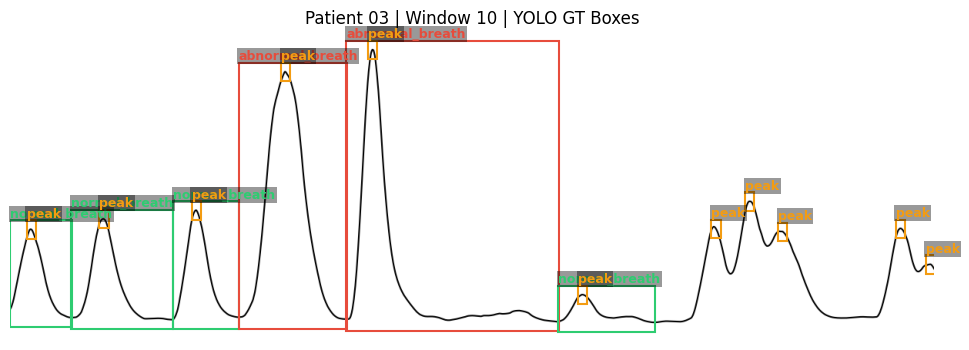

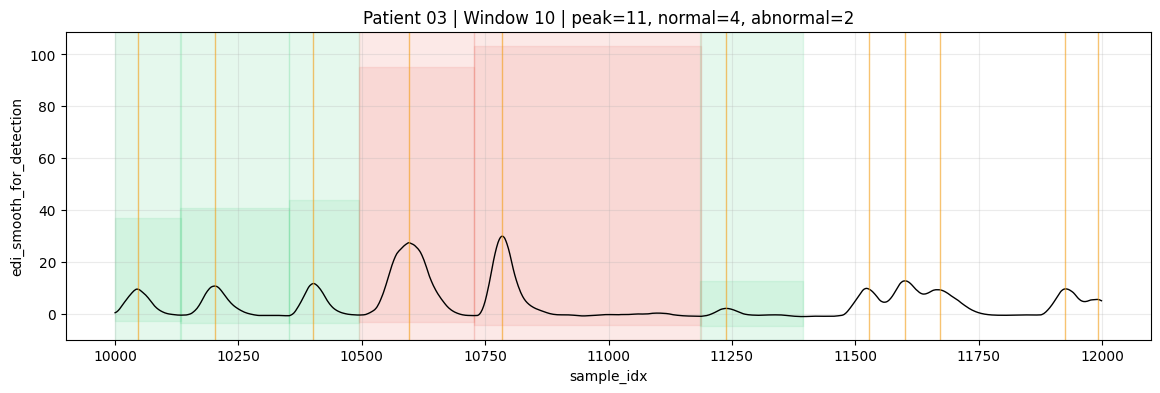

{'patient_id': '03',
 'window_idx': 10,
 'image': '/home/jhkim/NAVA/02_YOLO/data/4_BreathDetect_YOLO/20260301_win2000_stride1000_nogrid_relative/03/images/p03_w0010.png',
 'label': '/home/jhkim/NAVA/02_YOLO/data/4_BreathDetect_YOLO/20260301_win2000_stride1000_nogrid_relative/03/labels/p03_w0010.txt',
 'counts': {0: 11, 1: 4, 2: 2}}

In [33]:
# 환자/윈도우 지정
PATIENT_ID = '03'
WINDOW_IDX = 10

result = show_window(PATIENT_ID, WINDOW_IDX)
result


In [34]:
# 해당 환자에서 박스가 많은 윈도우 TOP-5를 보고 싶을 때
pid = str(PATIENT_ID).zfill(2)
label_dir = DATASET_ROOT / pid / 'labels'
rows = []
for lp in sorted(label_dir.glob('p*_w*.txt')):
    m = re.search(r'_w(\d+)\.txt$', lp.name)
    if not m:
        continue
    widx = int(m.group(1))
    n = len([ln for ln in lp.read_text(encoding='utf-8').splitlines() if ln.strip()])
    rows.append((widx, n))

top = sorted(rows, key=lambda t: t[1], reverse=True)[:5]
top


[(177, 30), (136, 29), (176, 29), (275, 28), (185, 27)]